-----

# **Transações Pix por Município**

## Descrição do conjunto de dados
Essa base fornece dados detalhados sobre as transações Pix liquidadas em nível municipal, discriminadas por pessoas físicas (PF) e jurídicas (PJ), sob as perspectivas do pagador e do recebedor.

-----

## Parâmetros de Consulta

Para acessar os dados, você pode utilizar os seguintes parâmetros:

  * **`DataBase`** (texto): Define a data-base para a consulta no formato `AAAAMM`.
  * **`$format`** (texto): Especifica o tipo de conteúdo de retorno.
  * **`$select`** (texto): Seleciona as propriedades a serem retornadas.
  * **`$filter`** (texto): Aplica filtros de seleção de entidades (por exemplo, `Nome eq 'João'`). Consulte as opções de operadores e funções [aqui](https://www.google.com/search?q=link-para-operadores-e-funcoes).
  * **`$orderby`** (texto): Ordena as entidades pelas propriedades especificadas (por exemplo, `Nome asc, Idade desc`).
  * **`$skip`** (inteiro): Define o índice inicial (maior ou igual a zero) da primeira entidade a ser retornada.
  * **`$top`** (inteiro): Define o número máximo (maior que zero) de entidades a serem retornadas.

-----

## Estrutura do Resultado

A consulta retornará os seguintes campos:

  * **`AnoMes`** (inteiro): Data-base no formato `AAAAMM`.
  * **`Municipio_Ibge`** (inteiro): Código IBGE do município.
  * **`Municipio`** (texto): Nome do município.
  * **`Estado_Ibge`** (inteiro): Código IBGE do estado.
  * **`Estado`** (texto): Nome do estado.
  * **`Sigla_Regiao`** (texto): Sigla da Região.
  * **`Regiao`** (texto): Região do país (Norte, Nordeste, Sul, Sudeste e Centro-Oeste).
  * **`VL_PagadorPF`** (decimal): Volume financeiro em R$ das transações cujo pagador é uma pessoa física (PF).
  * **`QT_PagadorPF`** (decimal): Quantidade de transações cujo pagador é uma pessoa física (PF).
  * **`VL_PagadorPJ`** (decimal): Volume financeiro em R$ das transações cujo pagador é uma pessoa jurídica (PJ).
  * **`QT_PagadorPJ`** (decimal): Quantidade de transações cujo pagador é uma pessoa jurídica (PJ).
  * **`VL_RecebedorPF`** (decimal): Volume financeiro em R$ das transações cujo recebedor é uma pessoa física (PF).
  * **`QT_RecebedorPF`** (decimal): Quantidade de transações cujo recebedor é uma pessoa física (PF).
  * **`VL_RecebedorPJ`** (decimal): Volume financeiro em R$ das transações cujo recebedor é uma pessoa jurídica (PJ).
  * **`QT_RecebedorPJ`** (decimal): Quantidade de transações cujo recebedor é uma pessoa jurídica (PJ).
  * **`QT_PES_PagadorPF`** (decimal): Quantidade de pagadores pessoas físicas.
  * **`QT_PES_PagadorPJ`** (decimal): Quantidade de pagadores pessoas jurídicas.
  * **`QT_PES_RecebedorPF`** (decimal): Quantidade de recebedores pessoas físicas.
  * **`QT_PES_RecebedorPJ`** (decimal): Quantidade de recebedores pessoas jurídicas.

## Análise Exploratória

Com o processo de ETL ja feito, vamos gerar um novo DataFrame a partir da consulta no banco de dados

Antes disso, podemos estabelecer algumas perguntas para guiar nossa análise: 
* Qual a média de valor Pix movimentado por pessoas físicas e por pessoas jurídicas?
* Qual foi a tendência de participação dos pagadores PJ nas transações ao longo dos meses em 2024?

Primeiramente, carregamos o dataframe com os dados:

In [47]:
import pandas as pd
import sqlite3

con = sqlite3.connect("src/datasets/etlbcb.db")
query = "select * from transacoesPixPorMunicipio"
df = pd.read_sql(query, con)
con.close()
df

,AnoMes,Municipio_Ibge,Municipio,Estado_Ibge,Estado,Sigla_Regiao,Regiao,VL_PagadorPF,QT_PagadorPF,VL_PagadorPJ,QT_PagadorPJ,VL_RecebedorPF,QT_RecebedorPF,VL_RecebedorPJ,QT_RecebedorPJ,QT_PES_PagadorPF,QT_PES_PagadorPJ,QT_PES_RecebedorPF,QT_PES_RecebedorPJ
0,2023-08-01 00:00:00,3110707,CAMBUQUIRA,31,MINAS GERAIS,SE,SUDESTE,20854173.13,113895,5278665.26,6439,23527894.24,77182,7403574.06,19416,5723,413,5773,416
1,2023-10-01 00:00:00,3110707,CAMBUQUIRA,31,MINAS GERAIS,SE,SUDESTE,24386904.46,125166,8125965.47,7143,24183164.04,81447,7432887.47,20989,5863,419,5919,421
2,2024-11-01 00:00:00,2907558,CATURAMA,29,BAHIA,NE,NORDESTE,10878560.97,65532,1020296.07,1472,10239267.84,37106,839365.11,4874,2795,68,2703,61
3,2023-03-01 00:00:00,3103108,ANTÔNIO PRADO DE MINAS,31,MINAS GERAIS,SE,SUDESTE,2171747.51,10736,140521.47,312,2336363.56,9100,141856.02,535,629,27,608,18
4,2023-06-01 00:00:00,3515806,FLORA RICA,35,SÃO PAULO,SE,SUDESTE,2372197.45,13525,425672.22,463,2240257.95,7760,476306.05,1177,720,17,703,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,2025-03-01 00:00:00,4215604,SANTA ROSA DE LIMA,42,SANTA CATARINA,SU,SUL,4993973.51,15862,4898769.96,1722,5068751.39,7488,4142262.42,17471,982,122,891,120
5996,2022-04-01 00:00:00,2302404,BOA VIAGEM,23,CEARÁ,NE,NORDESTE,40090462.33,196101,9021449.93,6766,39855526.99,173604,7996885.82,18039,13952,419,14601,402
5997,2024-11-01 00:00:00,1701002,ANANÁS,17,TOCANTINS,NO,NORTE,40903035.26,259992,8083675.92,9604,38262984.61,159782,8926946.07,28128,6546,287,6379,266
5998,2022-09-01 00:00:00,4110052,IGUATU,41,PARANÁ,SU,SUL,2326779.57,9191,1171638.64,646,2033189.07,6583,1276257.88,1728,755,45,697,44


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AnoMes              6000 non-null   object 
 1   Municipio_Ibge      6000 non-null   int64  
 2   Municipio           6000 non-null   object 
 3   Estado_Ibge         6000 non-null   int64  
 4   Estado              6000 non-null   object 
 5   Sigla_Regiao        6000 non-null   object 
 6   Regiao              6000 non-null   object 
 7   VL_PagadorPF        6000 non-null   float64
 8   QT_PagadorPF        6000 non-null   int64  
 9   VL_PagadorPJ        6000 non-null   float64
 10  QT_PagadorPJ        6000 non-null   int64  
 11  VL_RecebedorPF      6000 non-null   float64
 12  QT_RecebedorPF      6000 non-null   int64  
 13  VL_RecebedorPJ      6000 non-null   float64
 14  QT_RecebedorPJ      6000 non-null   int64  
 15  QT_PES_PagadorPF    6000 non-null   int64  
 16  QT_PES

Agora precisamos checar se existem valores nulos ou faltantes:

In [49]:
df.isnull().sum()

AnoMes                0
Municipio_Ibge        0
Municipio             0
Estado_Ibge           0
Estado                0
Sigla_Regiao          0
Regiao                0
VL_PagadorPF          0
QT_PagadorPF          0
VL_PagadorPJ          0
QT_PagadorPJ          0
VL_RecebedorPF        0
QT_RecebedorPF        0
VL_RecebedorPJ        0
QT_RecebedorPJ        0
QT_PES_PagadorPF      0
QT_PES_PagadorPJ      0
QT_PES_RecebedorPF    0
QT_PES_RecebedorPJ    0
dtype: int64

Percebemos que a coluna 'AnoMes' não está com o tipo de dado ideal, então iremos transformar para DateTime

In [50]:
df['AnoMes'] = df['AnoMes'].astype(str)
df['AnoMes'] = pd.to_datetime(df['AnoMes'])

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   AnoMes              6000 non-null   datetime64[ns]
 1   Municipio_Ibge      6000 non-null   int64         
 2   Municipio           6000 non-null   object        
 3   Estado_Ibge         6000 non-null   int64         
 4   Estado              6000 non-null   object        
 5   Sigla_Regiao        6000 non-null   object        
 6   Regiao              6000 non-null   object        
 7   VL_PagadorPF        6000 non-null   float64       
 8   QT_PagadorPF        6000 non-null   int64         
 9   VL_PagadorPJ        6000 non-null   float64       
 10  QT_PagadorPJ        6000 non-null   int64         
 11  VL_RecebedorPF      6000 non-null   float64       
 12  QT_RecebedorPF      6000 non-null   int64         
 13  VL_RecebedorPJ      6000 non-null   float64     

também podemos organizar os registros para que fiquem em ordem crescente baseado nas datas

In [52]:
df = df.sort_values(by='AnoMes', ascending=True)

Com as devidas correções feitas, agora podemos partir para a análise dos dados

## Análise dos Dados e Estatística Descritiva

Agora iremos utilizar as ferramentas necessárias para responder as perguntas geradas anteriormente.

In [62]:
#Média de valor Pix de Pessoa Física e de Pessoa jurídica
print(f'Média para PF: {df['VL_PagadorPF'].mean():.2f}')
print(f'Mediana para PF: {df['VL_PagadorPF'].median():.2f}')

print(f'Média para PJ: {df['VL_PagadorPJ'].mean():.2f}')
print(f'Mediana para PJ: {df['VL_PagadorPJ'].median():.2f}')

Média para PF: 66519634.80
Mediana para PF: 15265139.22
Média para PJ: 47728320.24
Mediana para PJ: 4103807.76


Para confirmar a confiabilidade da média, podemos utilizar uma medida de dispersão da estatística que é o Desvio-Padrão

In [61]:
# Calculando a variância
df_VlPagadorPF = df['VL_PagadorPF']

df_VlPagadorPJ = df['VL_PagadorPJ']



print(f'Desvio-padrão para PF: {df_VlPagadorPF.std():.2f}')

print(f'Desvio-padrão para PJ: {df_VlPagadorPJ.std():.2f}')

Desvio-padrão para PF: 227229930.73
Desvio-padrão para PJ: 214767583.12


Observa-se que os valores de média e de mediana se distanciam bastante.Além disso, a medida do desvio-padrão é altíssimo. Portanto, a média deixa de ser um valor confiável.

Agora vamos medir a participação de Pessoas Jurídicas nessas transações no ano de 2024

In [55]:
# Filtrando o atributo AnoMes para o ano de 2024
df_2024 = df[df['AnoMes'].dt.year == 2024]
df_2024



,AnoMes,Municipio_Ibge,Municipio,Estado_Ibge,Estado,Sigla_Regiao,Regiao,VL_PagadorPF,QT_PagadorPF,VL_PagadorPJ,QT_PagadorPJ,VL_RecebedorPF,QT_RecebedorPF,VL_RecebedorPJ,QT_RecebedorPJ,QT_PES_PagadorPF,QT_PES_PagadorPJ,QT_PES_RecebedorPF,QT_PES_RecebedorPJ
3072,2024-01-01,2106904,MONÇÃO,21,MARANHÃO,NE,NORDESTE,3.513603e+07,354180,3.728369e+06,4166,3.007548e+07,211908,4.536914e+06,19711,11250,120,10791,116
3729,2024-01-01,2701100,BRANQUINHA,27,ALAGOAS,NE,NORDESTE,1.564419e+07,149422,1.250283e+06,1858,1.456717e+07,88974,1.157437e+06,4125,4603,62,4596,57
5586,2024-01-01,3517604,GUAPIARA,35,SÃO PAULO,SE,SUDESTE,3.605732e+07,209996,1.408613e+07,9316,3.623439e+07,119497,1.294204e+07,21765,8609,334,8395,317
2321,2024-01-01,5207600,FAZENDA NOVA,52,GOIÁS,CO,CENTRO-OESTE,1.587269e+07,62337,4.272903e+06,3057,1.514370e+07,39535,4.893504e+06,7834,2552,155,2452,154
1357,2024-01-01,5201405,APARECIDA DE GOIÂNIA,52,GOIÁS,CO,CENTRO-OESTE,2.054785e+09,11233089,2.210376e+09,866939,2.201928e+09,7951137,2.081050e+09,2006987,344245,25120,350829,23429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4799,2024-12-01,3536257,PARISI,35,SÃO PAULO,SE,SUDESTE,9.783287e+06,40162,9.330221e+06,2338,9.414805e+06,22727,7.778390e+06,6309,1366,89,1369,83
4338,2024-12-01,3114907,CASA GRANDE,31,MINAS GERAIS,SE,SUDESTE,7.261330e+06,18462,1.385148e+06,910,6.130235e+06,11295,1.067865e+06,2140,1054,59,975,49
3811,2024-12-01,2608057,JATOBÁ,26,PERNAMBUCO,NE,NORDESTE,4.061056e+07,294960,8.511725e+06,5234,3.652147e+07,183291,7.124789e+06,22706,7565,169,7358,155
4364,2024-12-01,5212501,LUZIÂNIA,52,GOIÁS,CO,CENTRO-OESTE,9.355687e+08,5976438,5.532040e+08,321997,9.507971e+08,3744527,4.676327e+08,981762,133945,7884,135692,7341


In [ ]:
#Criando uma nova coluna para obter as contribuições totais para as transações por Pix
df_2024['VL_PagadoresCombinados'] = df_2024['VL_PagadorPF'] + df_2024['VL_PagadorPJ']
total_combinado = df_2024['VL_PagadoresCombinados'].sum()
total_pj = df_2024['VL_PagadorPJ'].sum()

#Obtendo e exibindo o percentual total de movimentações via Pix por Pessoas Jurídicas
percentual_pj = (total_pj / total_combinado) * 100
print(f"Percentual de participação das PJ: {percentual_pj:.2f}%")


Percentual de participação das PJ: 42.13%


C:\Users\malul\AppData\Local\Temp\ipykernel_13396\859190329.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['VL_PagadoresCombinados'] = df_2024['VL_PagadorPF'] + df_2024['VL_PagadorPJ']


In [65]:
# Baseando-se agora na quantidade de pagadores:
totalPF = df_2024['QT_PES_PagadorPF'].sum()
totalPJ = df_2024['QT_PES_PagadorPJ'].sum()
print(f'Quantidade de pagadores do tipo Pessoa Física: {totalPF}')
print(f'Quantidade de pagadores do tipo Pessoa Física: {totalPJ}')

Quantidade de pagadores do tipo Pessoa Física: 25187135
Quantidade de pagadores do tipo Pessoa Física: 1515765


Percebe-se que as contribuições por Pessoas Físicas foram maiores no ano de 2024.

## Visualização dos dados

Podemos gerar visualizações gráficas para facilitar no entendimento dos dados que estamos analisando. Nesse caso, vamos usa-las para comparar as contribuições de pessoas física e jurídica no ano de 2024

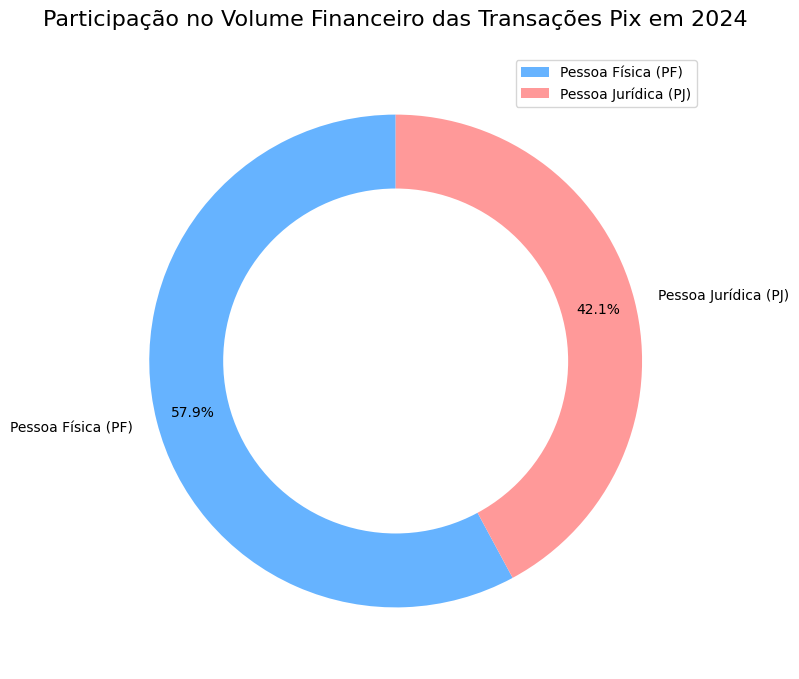

In [67]:
import matplotlib.pyplot as plt
total_pf_volume = df_2024['VL_PagadorPF'].sum()
total_pj_volume = df_2024['VL_PagadorPJ'].sum()

labels = ['Pessoa Física (PF)', 'Pessoa Jurídica (PJ)']
sizes = [total_pf_volume, total_pj_volume]
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(8, 8)) 
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        pctdistance=0.85, wedgeprops=dict(width=0.4)) 

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Participação no Volume Financeiro das Transações Pix em 2024', fontsize=16, pad=20)

plt.legend(labels, loc="best")
plt.show()



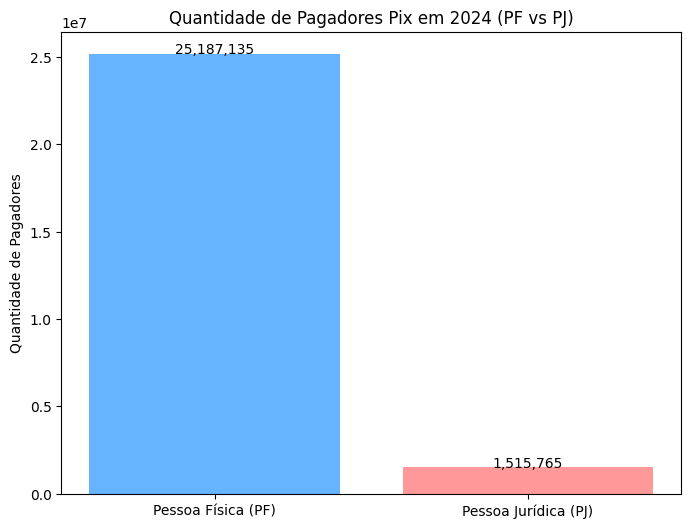

In [70]:
total_pf_pagadores = df_2024['QT_PES_PagadorPF'].sum()
total_pj_pagadores = df_2024['QT_PES_PagadorPJ'].sum()

categorias = ['Pessoa Física (PF)', 'Pessoa Jurídica (PJ)']
quantidades = [total_pf_pagadores, total_pj_pagadores]
cores_barras = ['#66b3ff', '#ff9999'] 


plt.figure(figsize=(8, 6)) 
plt.bar(categorias, quantidades, color=cores_barras)

plt.ylabel('Quantidade de Pagadores')
plt.title('Quantidade de Pagadores Pix em 2024 (PF vs PJ)')

for i, quantidade in enumerate(quantidades):
    plt.text(i, quantidade + 50, f'{quantidade:,.0f}', ha='center')

plt.show()

In [71]:
df.to_csv('transacoesPix.csv', sep=';', decimal=',')